<a href="https://colab.research.google.com/github/Aleem-mja/DeepLearning-Project-SLIIT-SE4050/blob/IT22918406/it22918406.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Imports, seeds, hyperparameters
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Key knobs aligned to IMDB
MAX_FEATURES = 10000   # keep top 10k most frequent words
MAXLEN = 500           # pad/truncate each review to 500 tokens
EMBED_DIM = 128
RNN_UNITS = 64
BATCH_SIZE = 128
EPOCHS = 10
VAL_SAMPLES = 5000

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)


In [ ]:
# Load IMDB and preprocess
print("Loading IMDB dataset...")
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=MAX_FEATURES)

# Pad sequences to uniform length
x_train = pad_sequences(x_train, maxlen=MAXLEN)
x_test  = pad_sequences(x_test,  maxlen=MAXLEN)

print(f"Train (before split): {x_train.shape}, Test: {x_test.shape}")

# Validation split from the tail of training data
x_val = x_train[-VAL_SAMPLES:]
y_val = y_train[-VAL_SAMPLES:]
x_train = x_train[:-VAL_SAMPLES]
y_train = y_train[:-VAL_SAMPLES]

print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")


Loading IMDB dataset...
Train (before split): (25000, 500), Test: (25000, 500)
Train: (20000, 500), Val: (5000, 500), Test: (25000, 500)


In [ ]:
 # Build the RNN model (from scratch)
def build_rnn_model(max_features=MAX_FEATURES, embed_dim=EMBED_DIM,
                    rnn_units=RNN_UNITS, maxlen=MAXLEN, dropout_rate=0.5):
    model = Sequential([
        Embedding(max_features, embed_dim, input_length=maxlen),  # learned during training
        SimpleRNN(rnn_units, return_sequences=True),
        SimpleRNN(rnn_units),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')  # probability of "positive"
    ])
    return model

# Compile and summarize the model
model = build_rnn_model()
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train and save
print("Training...")

history = model.fit(
    x_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(x_val, y_val),
    verbose=1
)

save_path = os.path.join(MODEL_DIR, "imdb_rnn_model.h5")
model.save(save_path)
print(f"Saved model to: {save_path}")


Training...
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 61s 369ms/step - accuracy: 0.5708 - loss: 0.6809 - val_accuracy: 0.8276 - val_loss: 0.4018
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 354ms/step - accuracy: 0.8294 - loss: 0.3996 - val_accuracy: 0.8394 - val_loss: 0.3758
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 58s 368ms/step - accuracy: 0.8988 - loss: 0.2554 - val_accuracy: 0.8500 - val_loss: 0.4418
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 83s 374ms/step - accuracy: 0.9409 - loss: 0.1668 - val_accuracy: 0.7748 - val_loss: 0.6207
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 60s 384ms/step - accuracy: 0.9705 - loss: 0.0829 - val_accuracy: 0.7596 - val_loss: 0.7586
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 80s 369ms/step - accuracy: 0.9668 - loss: 0.0898 - val_accuracy: 0.7278 - val_loss: 0.9137
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 84s 379ms/step - accuracy: 0.9914 - loss: 0.0291 - val_accuracy: 0.7698 - val_loss: 0.9608
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 359ms/step - accuracy: 0.99

Saved model to: models/imdb_rnn_model.h5


In [ ]:
# Evaluate on test data
print("Evaluating on test data...")

y_prob = model.predict(x_test, batch_size=BATCH_SIZE)
y_pred = (y_prob > 0.5).astype(int).flatten()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}")


Evaluating on test data...
196/196 ━━━━━━━━━━━━━━━━━━━━ 21s 109ms/step
Accuracy : 0.8055
Precision: 0.8111
Recall   : 0.7966
F1 Score : 0.8038


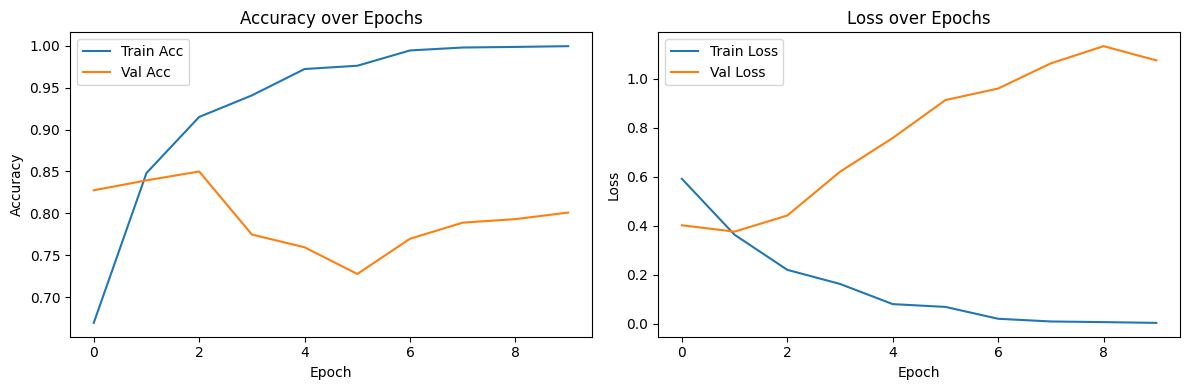

In [ ]:
# Plot training & validation curves
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


In [ ]:
# Predict sentiment for new text
word_index = imdb.get_word_index()
index_offset = 3  # IMDB reserves 0:<PAD>, 1:<START>, 2:<UNK>

def text_to_sequence(text, word_index=word_index, maxlen=MAXLEN):
    words = text.lower().split()
    seq = []
    for w in words:
        idx = word_index.get(w)
        seq.append(idx + index_offset if idx is not None else 2)  # map OOV to <UNK>=2
    return pad_sequences([seq], maxlen=maxlen)

def predict_sentiment(text):
    seq = text_to_sequence(text)
    prob = float(model.predict(seq)[0][0])
    label = "Positive" if prob > 0.5 else "Negative"
    return {"text": text, "label": label, "confidence": prob}

# Example
example = "This movie was fantastic! The acting was superb and the plot kept me engaged."
print(predict_sentiment(example))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
{'text': 'This movie was fantastic! The acting was superb and the plot kept me engaged.', 'label': 'Negative', 'confidence': 0.0018885290483012795}


In [ ]:
# Project note for your report
note = """
This project performs binary sentiment analysis on the Keras IMDB dataset (50k labeled
reviews).
After loading integer-encoded reviews and padding to a fixed length (500 tokens), we train a
from-scratch neural model: Embedding -> SimpleRNN -> SimpleRNN -> Dropout ->
Dense(sigmoid).
The embedding and RNN weights are randomly initialized and learned entirely on IMDB (no
pretrained weights). We train with Adam + binary cross-entropy, monitor validation metrics,
evaluate on the held-out test split using Accuracy/Precision/Recall/F1, and provide a helper
to score new review strings. This implements an end-to-end baseline sentiment classifier
suitable for demos and as a starting point before upgrading to LSTM/GRU or pretrained
Transformers.
"""
print(note)



This project performs binary sentiment analysis on the Keras IMDB dataset (50k labeled
reviews).
After loading integer-encoded reviews and padding to a fixed length (500 tokens), we train a
from-scratch neural model: Embedding -> SimpleRNN -> SimpleRNN -> Dropout ->
Dense(sigmoid).
The embedding and RNN weights are randomly initialized and learned entirely on IMDB (no
pretrained weights). We train with Adam + binary cross-entropy, monitor validation metrics,
evaluate on the held-out test split using Accuracy/Precision/Recall/F1, and provide a helper
to score new review strings. This implements an end-to-end baseline sentiment classifier
suitable for demos and as a starting point before upgrading to LSTM/GRU or pretrained
Transformers.

